# Setup

In [7]:
from pprint import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seed
seed = 42

# sklearn config
from sklearn import set_config
set_config(transform_output='pandas', display='text')

# 1. K-Means

## 1) Summary

### Algorithm

1. Init $C_k$, $1 \le k \le K$,
2. For $x_i$ in $1 \le i \le m$, $y_i = \min_k d(x_i, C_k)$,
3. For $C_k$, $C_k' = \frac{1}{m_k}\sum_{j:y_j=k} x_j$, where $m_k$ = Number of samples whose cluster is k.
4. Repeat 2-3 until
   1) max_iter
   2) $\max_k \|C_k' - C_k\| < \epsilon$
   3) No change in $y_i$ for $\forall i$.

### Centroid Initialization

-  Random init
    - Randomly choose from samples.
- K++
    - Randomly choose the first centroid, $c_1$.
    - Calculate the distance $d_i = \min_k \|x_i-C_k\|$
    - Calculate $p_i = \frac{d_i^2}{\sum_{j \ne i} d_j^2}$
    - Choose the next $c_k$ according to the $p_i$.
    - Repeat for $c_2$ ~ $c_K$.
    - Repeat `n_init` times $\rightarrow$ choose the $c_k$ where the inertia is minimal.

### K / Evaluation

- Inertia
  - $Inertia = \sum_{k=1}^{K}\sum_{i:y_i \in k}\|x_i-C_k\|^2$
  - Choose the $K$ from the elbow point.
- Silhouette score
  - $s_i = \frac{b_i-a_i}{\max(a_i,b_i)}$
    - $a_i$ = an average distance between samples in the same cluster $c_k$
    - $b_i$ = an average distance from nearest cluster.
    - Nearest cluster = a cluster where the average distance from all samples is minimal.

### Time Complexity

- Train: $O(T \times m \times n \times K)$
  - $T$ = n_iter
  - $m$ = n_samples
  - $n$ = n_features
  - $K$ = n_centroids
- Inference: $O(m \times n \times K)$

### Practical tips

- Usage: a good baseline.
- Feature scaling is mandatory.
- Sensitive to outlier, because $C_k$ = mean of samples.
- Doesn't work well for non-convex clusters.

> Note) Convex vs Concave  
> - Convex function: $f(\frac{x_1+x_2}{2}) \le \frac{f(x_1)+f(x_2)}{2}$  
> - Concave function: $f(\frac{x_1+x_2}{2}) \ge \frac{f(x_1)+f(x_2)}{2}$  
> - Convex Set  
>   - for $\forall x_i, x_j \in C$ and $\lambda \in [0,1]$, $\lambda x_i + (1-\lambda)x_j \in C$.  
>   - Any entire line $x_i-x_j$ should be in the $C$.  
>   - Convex region : Convex set-like shape.  

## 2) API

```python
from sklearn.cluster import KMeans

class KMeans(
    n_clusters: Int = 8,
    *,
    init: Literal['k-means++', 'random'] | ArrayLike | Callable = "k-means++",
    n_init: Int | Literal['auto'] = "auto",
    max_iter: Int = 300,
    tol: Float = 0.0001,
    verbose: Int = 0,
    random_state: Int | RandomState | None = None,
    copy_x: bool = True,
    algorithm: Literal['lloyd', 'elkan'] = "lloyd"
)
```

# 2. DBSCAN

## 1) Summary

### Algorithm

- Hyperparameters
  - $\epsilon$ (`eps`) = the maximum distance that a nearby sample is considered as a neighbor.
  - $\mathrm{min\_samples}$ (`min_samples`) = a minimum number of neighbors that a sample is considered as the core sample.

1. For each $x_i$, find its neighbors:
    - $N_\epsilon(x_i) = \{x_j : d(x_i,x_j) \le \epsilon\}$
2. For each $x_i$, determine the type:
    - Core: $|N_\epsilon(x_i)| \ge \mathrm{min\_samples}$, including $x_i$ itself.
    - Border: not core, but within $\epsilon$ of a core sample.
    - Noise: neither core nor border.
3. For each unassigned core sample,
    - Create a new cluster including the core sample.
    - Include its all neighbors.
    - If the included neighbor is also a core sample, include its all neighbors too.
4. Repeat 3 until all core samples are assigned.
    - `-1` for noise samples.

### Parameters / Evaluation

- `eps`
  - Neighborhood radius, not a maximum cluster diameter.
  - Too small $\rightarrow$ many noise samples
  - Too large $\rightarrow$ separate clusters may merge.
  - Sort each sample's distance to its `min_samples`-th nearest sample, counting itself.
  - Choose `eps` near the elbow of this k-distance plot.
- `min_samples`
  - Higher value $\rightarrow$ a stricter density requirement.
- Evaluation
  - Cluster sizes, shapes, and the noise ratio.
  - Silhouette: exclude noise and require at least two remaining clusters.
    - Silhouette favors convex clusters, so do not rely on it alone.

### Time Complexity

- Train
  - Typical: $O(m \log m)$ with efficient neighbor search, fixed low dimension, and small neighborhoods.
  - Worst / brute force: $O(m^2 \times n)$.
  - $m$ = n_samples
  - $n$ = n_features
- Inference
  - No `predict` in sklearn.
  - `fit_predict` labels the training samples.
- Memory
  - Up to $O(m^2)$ in `sklearn`.

### Practical tips

- Usage: non-convex clusters and noise detection.
- Scale features before choosing `eps`.
- Different cluster densities can make one `eps` unsuitable; consider HDBSCAN or OPTICS.
- For a new sample, DBSCAN should cluster all samples from scratch, because shared border samples may change clusters when the input order changes.

## 2) API

```python
from sklearn.cluster import DBSCAN

class DBSCAN(
    *,
    eps: Float = 0.5,
    min_samples: Int = 5,
    metric: str | Callable = "euclidean",
    metric_params: dict | None = None,
    algorithm: Literal['auto', 'ball_tree', 'kd_tree', 'brute'] = "auto",
    leaf_size: Int = 30,
    p: Float | None = None,
    n_jobs: Int | None = None
)
```

# 3. Agglomerative Clustering

## 1) Summary

### Algorithm

1. Init one cluster per sample: $C_i = \{x_i\}$, $1 \le i \le m$.
2. Find the pair of clusters with the smallest linkage distance.
3. Merge them and update the distances to the other clusters.
4. Repeat 2-3 until $K$ clusters remain, or cut the merge tree at `distance_threshold`.
   - The merge tree is called a dendrogram.

### Linkage

- Single
  - $d(A,B) = \min_{x_i \in A,\,x_j \in B} d(x_i,x_j)$
  - Can find non-convex clusters, but noisy bridges can connect separate clusters (chaining).
- Complete
  - $d(A,B) = \max_{x_i \in A,\,x_j \in B} d(x_i,x_j)$
- Average
  - $d(A,B) = \frac{1}{|A||B|}\sum_{x_i \in A}\sum_{x_j \in B} d(x_i,x_j)$
- Ward
  - Merge the pair with the smallest increase in inertia.
  - $\Delta I(A,B) = \frac{|A||B|}{|A|+|B|}\|\mu_A-\mu_B\|^2$, where $\mu_A,\mu_B$ = cluster means.
  - Uses Euclidean distance and favors compact clusters.

### K / Evaluation

- `n_clusters`
  - Compare $K$ using silhouette scores and the dendrogram.
  - A cut before a large jump in merge distance can be a useful choice.
- `distance_threshold`
  - An alternative to specifying $K$.
  - Merges at or above this linkage distance are excluded.
  - Set `n_clusters=None` and `compute_full_tree=True`.

### Time Complexity

- Train
  - Typically $O(m^2 \times n)$ for dense Euclidean data without a connectivity constraint.
  - $m$ = n_samples
  - $n$ = n_features
- Inference
  - No `predict` in sklearn.
  - `fit_predict` labels the training samples.
- Memory: up to $O(m^2)$.

### Practical tips

- Usage: hierarchical structure and comparing different levels of clustering.
- Scale features when their units or ranges differ.
- Greedy merging: an earlier merge cannot be undone.
- `connectivity` restricts merges to neighboring groups, useful for spatial structure.

## 2) API

```python
from sklearn.cluster import AgglomerativeClustering

class AgglomerativeClustering(
    n_clusters: Int | None = 2,
    *,
    metric: str | Callable = "euclidean",
    memory: str | Memory | None = None,
    connectivity: ArrayLike | SparseMatrix | Callable | None = None,
    compute_full_tree: bool | Literal['auto'] = "auto",
    linkage: Literal['ward', 'complete', 'average', 'single'] = "ward",
    distance_threshold: Float | None = None,
    compute_distances: bool = False
)
```

```python
from scipy.cluster.hierarchy import linkage, dendrogram

# X: (n_samples, n_features)
Z = linkage(X, method='ward')   # 'single', 'complete', 'average', 'ward'.

dendrogram(Z)
plt.show()
```

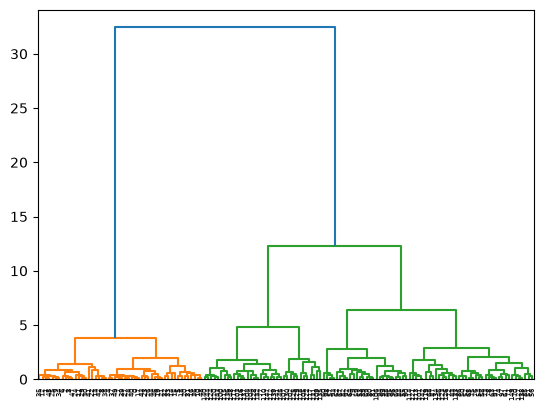

In [8]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram

X, y = load_iris(return_X_y=True, as_frame=True)

Z = linkage(X, method='ward')

dendrogram(Z)

plt.show()

# 4. Affinity Propagation

## 1) Summary

### Algorithm

1. Treat each sample $x_k$ as a candidate exemplar (representative sample).
2. Calculate similarities $s(i,k) = -\|x_i-x_k\|^2$ and replace $s(k,k)$ with preference $p_k$.
3. Init responsibility $r(i,k) = 0$ and availability $a(i,k) = 0$.
4. Update $r$ and $a$ with damping.
5. Repeat 4 until the nonempty set of exemplars stays unchanged for `convergence_iter` iterations, or `max_iter` is reached.
6. Select exemplars where $r(k,k)+a(k,k)>0$ and assign other samples to their most similar exemplar.

### Message Updates

- Responsibility
  - How suitable $x_k$ is as an exemplar for $x_i$, compared with other candidates.
  - $r(i,k) \leftarrow s(i,k)-\max_{j \ne k}\{a(i,j)+s(i,j)\}$
- Availability
  - How much support $x_k$ has to represent $x_i$, considering other samples.
  - $a(i,k) \leftarrow \min\{0,\,r(k,k)+\sum_{j \notin \{i,k\}}\max(0,r(j,k))\}$, for $i \ne k$.
  - $a(k,k) \leftarrow \sum_{j \ne k}\max(0,r(j,k))$
- Damping
  - $v \leftarrow \lambda v_{\mathrm{old}}+(1-\lambda)v_{\mathrm{new}}$, for both $r$ and $a$.
  - `damping` = $\lambda \in [0.5,1)$.
  - Reduces oscillation by retaining part of the previous value.

### K / Evaluation

- `preference`
  - Controls the tendency of each sample to become an exemplar; $K$ is not specified directly.
  - Larger values usually give more clusters.
  - Default: median of the input similarities.
- Silhouette score
  - Compare preference values using silhouette scores and meaningful cluster sizes.

### Time Complexity

- Train: $O(m^2 \times n + T \times m^2)$.
  - Similarity calculation: $O(m^2 \times n)$.
  - Message updates: $O(T \times m^2)$.
  - $T$ = n_iter
  - $m$ = n_samples
  - $n$ = n_features
  - $K$ = n_exemplars
- Inference: $O(m \times n \times K)$ for new samples with `affinity="euclidean"`.
  - `predict` is not supported with `affinity="precomputed"`.
- Memory: $O(m^2)$.

### Practical tips

- Usage: choose actual samples as representatives, rather than means.
- Best suited to small / medium datasets because of pairwise time and memory costs.
- Scale features when using Euclidean similarity.
- `affinity="precomputed"` expects similarities (larger = closer), not raw distances.
- Check convergence warnings; increasing `damping` or `max_iter` may help.

## 2) API

```python
from sklearn.cluster import AffinityPropagation

class AffinityPropagation(
    *,
    damping: Float = 0.5,
    max_iter: Int = 200,
    convergence_iter: Int = 15,
    copy: bool = True,
    preference: ArrayLike | Float | None = None,
    affinity: Literal['euclidean', 'precomputed'] = "euclidean",
    verbose: bool = False,
    random_state: Int | RandomState | None = None
)
```

# Evaluation

- Inertia, $I = \displaystyle\sum_{k=1}^{K}\displaystyle\sum_{i:y_i=k}\|x_i-C_k\|^2$
- Silhouette score, $s_i = \frac{b_i-a_i}{\max(a_i,b_i)}$
- ARI, Adjusted Rand Index
  - $RI = \frac{n\_correct\_pairs}{n\_pairs}$
  - $ARI = \frac{RI - E[RI]}{1 - E[RI]}$, where $E[RI] = pr(\text{both in same cluster}) + pr(\text{both in diff cluster})$
- NMI, Normalized Mutual Information
  - How much knowing the predicted cluster is informative to know the real cluster?
  - $NMI(U,V) = \frac{2MI(U,V)}{H(U)+H(V)}$
- Stability accross repetition
- Domain rules: cluster size/deviation, etc.

In [ ]:
from itertools import combinations
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

# Data
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42,
)

# Model
model = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=seed,
)

# Prediction
y_pred = model.fit_predict(X)

# Metrics
model.inertia_
silhouette_score(X, y_pred)
adjusted_rand_score(y_true, y_pred)
normalized_mutual_info_score(y_true, y_pred)

# Stability
runs = [
    KMeans(n_clusters=3, n_init=10, random_state=i).fit_predict(X)
    for i in range(5)
]
stability = np.mean([
    adjusted_rand_score(a, b)
    for a, b in combinations(runs, 2)
])

# Cluster size
cluster_sizes = np.bincount(y_pred)

# Cluster deviation
cluster_deviation = np.array([
    np.mean(np.linalg.norm(
        X[y_pred == k] - model.cluster_centers_[k],
        axis=1,
    ))
    for k in range(model.n_clusters)
])